# 💳️ Fraud Detection

Imbalanced classification

## 0. Overview

### 🎯 0.1 Objectives:

Target variable: Fraud binary labelling detection

1. Train a model on the fintech dataset
    * Evaluate on baselines
    * Evaluate different regression tree and boosted models
    * Practice stacked generalization modelling on the data
    * Determine best type of model
2. List which features are the most important to fraud detection - conduct SHAP
3. Deploy the model

### Key Findings:

### Project Context

Dataset from [Kaggle](https://www.kaggle.com/datasets/safar1/central-asia-fintech-fraud-dataset)
> Plan to have a small team of fraud analysts who review risky-looking purchases and decide whether to allow or block the transaction. This team will have the capacity to review 400 transactions a month. The outputs/results from your model will be used to decide which transactions the fraud analysts should review. The bank is requesting that after working these alerts, as much fraud value as possible has been prevented. If possible, the client also wants the model to be as explainable as possible.
The bank has provided 1 year of historical transactional data and fraud flags and asked you to build a model which predicts the likelihood that a transaction is later marked as fraud. 

Importing

In [1]:
from utils import *
import importlib
from optuna.integration import XGBoostPruningCallback
from optuna.integration import LightGBMPruningCallback

import os
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import math
import scipy.stats as stats
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import kruskal
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import (IterativeImputer, SimpleImputer)
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, recall_score, precision_score, classification_report
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
import joblib
import warnings
from sklearn.exceptions import SkipTestWarning
warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used",
    category=UserWarning,
)
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import shap
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

%matplotlib inline

sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
palette = ["gray", "darkgoldenrod"]
sns.set_palette(["darkgoldenrod", "gray"])

/home/linuxg/miniconda3/lib/python3.13/importlib/__init__.py:88: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)
/home/linuxg/miniconda3/lib/python3.13/importlib/__init__.py:88: FutureWarning: `optuna.integration.lightgbm` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.lightgbm` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


View of full imported dataset

In [2]:
tx = pd.read_csv("data/transactions.csv", parse_dates=["timestamp"])
users = pd.read_csv("data/users.csv", parse_dates=["registration_date"])
merchants = pd.read_csv("data/merchants.csv")

df = tx.merge(users, on="user_id", how="left").merge(
    merchants, on="merchant_id", how="left", suffixes=("_user", "_merchant")
)

print(f"Shape: {df.shape}")
print(df["is_fraud"].value_counts())
print(f"Fraud rate: {df.is_fraud.mean():.2%}")

Shape: (150000, 34)
is_fraud
0    144795
1      5205
Name: count, dtype: int64
Fraud rate: 3.47%


Imported 150,000 points of data with a 3% presence of fraud rate.

In [3]:
df.head()

,tx_id,timestamp,user_id,merchant_id,amount_uzs,channel,hour_of_day,day_of_week,is_weekend,session_duration_sec,...,historical_tx_count,merchant_name,category,city_merchant,region_merchant,mcc_code,risk_score,avg_transaction_uzs,is_online,years_registered
0,T00000000,2023-01-01 00:02:02,U000611,M01182,92883,qr,0,6,1,502,...,378,Shams Store,Telecom,Termez,Surxondaryo,5107,44.3,141766,0,9
1,T00000001,2023-01-01 00:08:28,U001904,M01090,35578,web,0,6,1,325,...,189,Baraka Bozor,Grocery,Guliston,Sirdaryo,6245,27.4,157290,1,2
2,T00000002,2023-01-01 00:15:25,U010006,M02389,229695,web,0,6,1,17,...,185,Nur Market,Fuel,Samarkand,Samarkand,8623,42.3,394316,0,5
3,T00000003,2023-01-01 00:16:27,U010291,M00743,134764,app,0,6,1,24,...,43,Nur Trade,Fuel,Andijan,Andijan,5476,25.2,240870,1,1
4,T00000004,2023-01-01 00:20:50,U003685,M01892,650334,qr,0,6,1,133,...,503,Baxt Service,Electronics,Guliston,Sirdaryo,9500,44.5,81823,0,3


## Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tx_id                 150000 non-null  str           
 1   timestamp             150000 non-null  datetime64[us]
 2   user_id               150000 non-null  str           
 3   merchant_id           150000 non-null  str           
 4   amount_uzs            150000 non-null  int64         
 5   channel               150000 non-null  str           
 6   hour_of_day           150000 non-null  int64         
 7   day_of_week           150000 non-null  int64         
 8   is_weekend            150000 non-null  int64         
 9   session_duration_sec  150000 non-null  int64         
 10  login_attempts        150000 non-null  int64         
 11  is_cross_city_tx      150000 non-null  int64         
 12  is_fraud              150000 non-null  int64         
 13  name      

### Features:

From transactions:
| Column | Description |
|---|---|
| tx_id | Unique transaction ID |
| timestamp | Transaction datetime (UTC+5) |
| user_id | FK → users |
| merchant_id | FK → merchants |
| amount_uzs | Amount in Uzbek Som |
| channel | app, web, pos, qr, ussd |
| hour_of_day | 0–23 |
| day_of_week | 0=Mon, 6=Sun |
| is_weekend | Weekend flag |
| session_duration_sec | Session length before tx |
| login_attempts | Login attempts in session |
| is_cross_city_tx | User city ≠ merchant city |
| is_fraud | Target — 1 = fraudulent |

User data from users csv:
| Column | Description |
|---|---|
| name | Uzbek full name |
| gender | M / F |
| age | 18–72 |
| city_user | User home city |
| region_user | User administrative region |
| registration_date | Account opening date |
| primary_app | Preferred payment app |
| preferred_device | Android / iOS / Web / USSD |
| credit_score | 300–850 |
| monthly_income_uzs | Monthly income in UZS |
| identity_verified | KYC verification status |
| historical_tx_count | All-time transaction count |

Merchant data from merchants.csv:
| Column | Description |
|---|---|
| merchant_name | Business name |
| category | Business category (12 types) |
| city_merchant | Merchant location |
| region_merchant | Merchant administrative region |
| mcc_code | Merchant Category Code |
| risk_score | Platform risk score (0–100) |
| avg_transaction_uzs | Merchant average transaction size |
| is_online | Online merchant flag |
| years_registered | Years on platform |

All 34 features will be used to detect fraud and provide more info on these instances.

In [5]:
print("Null values in the df: ", df.isna().sum().sum())
percent_nulls = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Percent of missing values present: {percent_nulls:.2f}%")

print("Duplicate values in the df: ", df.duplicated().sum())
percent_duplicates = (df.duplicated().sum() / len(df)) * 100
print(f"Percent of duplicates present: {percent_duplicates:.2f}%")

Null values in the df:  0
Percent of missing values present: 0.00%


Duplicate values in the df:  0
Percent of duplicates present: 0.00%


✅ No nulls present

✅ No duplicates present

### Feature Engineering

Account age, a useful feature given that new accounts are associated with suspicious activity, can be derived from timestamp and registration date. 

In [6]:
df["account_age"] = (df["timestamp"] - df["registration_date"]).dt.days

## 2. Exploratory Data Analysis

In [7]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numerical: {len(num_cols)}")
print(f"Categorical: {len(cat_cols)}")
print(f"\nNumerical: {num_cols}")
print(f"\nCategorical: {cat_cols}")

Numerical: 19
Categorical: 14

Numerical: ['amount_uzs', 'hour_of_day', 'day_of_week', 'is_weekend', 'session_duration_sec', 'login_attempts', 'is_cross_city_tx', 'is_fraud', 'age', 'credit_score', 'monthly_income_uzs', 'identity_verified', 'historical_tx_count', 'mcc_code', 'risk_score', 'avg_transaction_uzs', 'is_online', 'years_registered', 'account_age']

Categorical: ['tx_id', 'user_id', 'merchant_id', 'channel', 'name', 'gender', 'city_user', 'region_user', 'primary_app', 'preferred_device', 'merchant_name', 'category', 'city_merchant', 'region_merchant']


/tmp/ipykernel_128516/806901043.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,150000,2023-12-31 22:03:33.789906,2023-01-01 00:02:02,2023-07-01 21:26:26,2023-12-31 16:17:24.500000,2024-07-01 16:48:04.500000,2024-12-30 23:57:45,NaN
amount_uzs,150000.0,273481.92216,1048.0,71237.25,149080.0,315327.25,17909240.0,411689.641848
hour_of_day,150000.0,11.519673,0.0,6.0,12.0,18.0,23.0,6.916038
day_of_week,150000.0,2.993793,0.0,1.0,3.0,5.0,6.0,2.005421
is_weekend,150000.0,0.286093,0.0,0.0,0.0,1.0,1.0,0.451935
session_duration_sec,150000.0,453.073827,5.0,229.0,453.0,678.0,899.0,258.761973
login_attempts,150000.0,2.2655,1.0,1.0,2.0,4.0,5.0,1.477068
is_cross_city_tx,150000.0,0.91506,0.0,1.0,1.0,1.0,1.0,0.278793
is_fraud,150000.0,0.0347,0.0,0.0,0.0,0.0,1.0,0.183019
age,150000.0,44.32458,18.0,31.0,44.0,58.0,71.0,15.512201


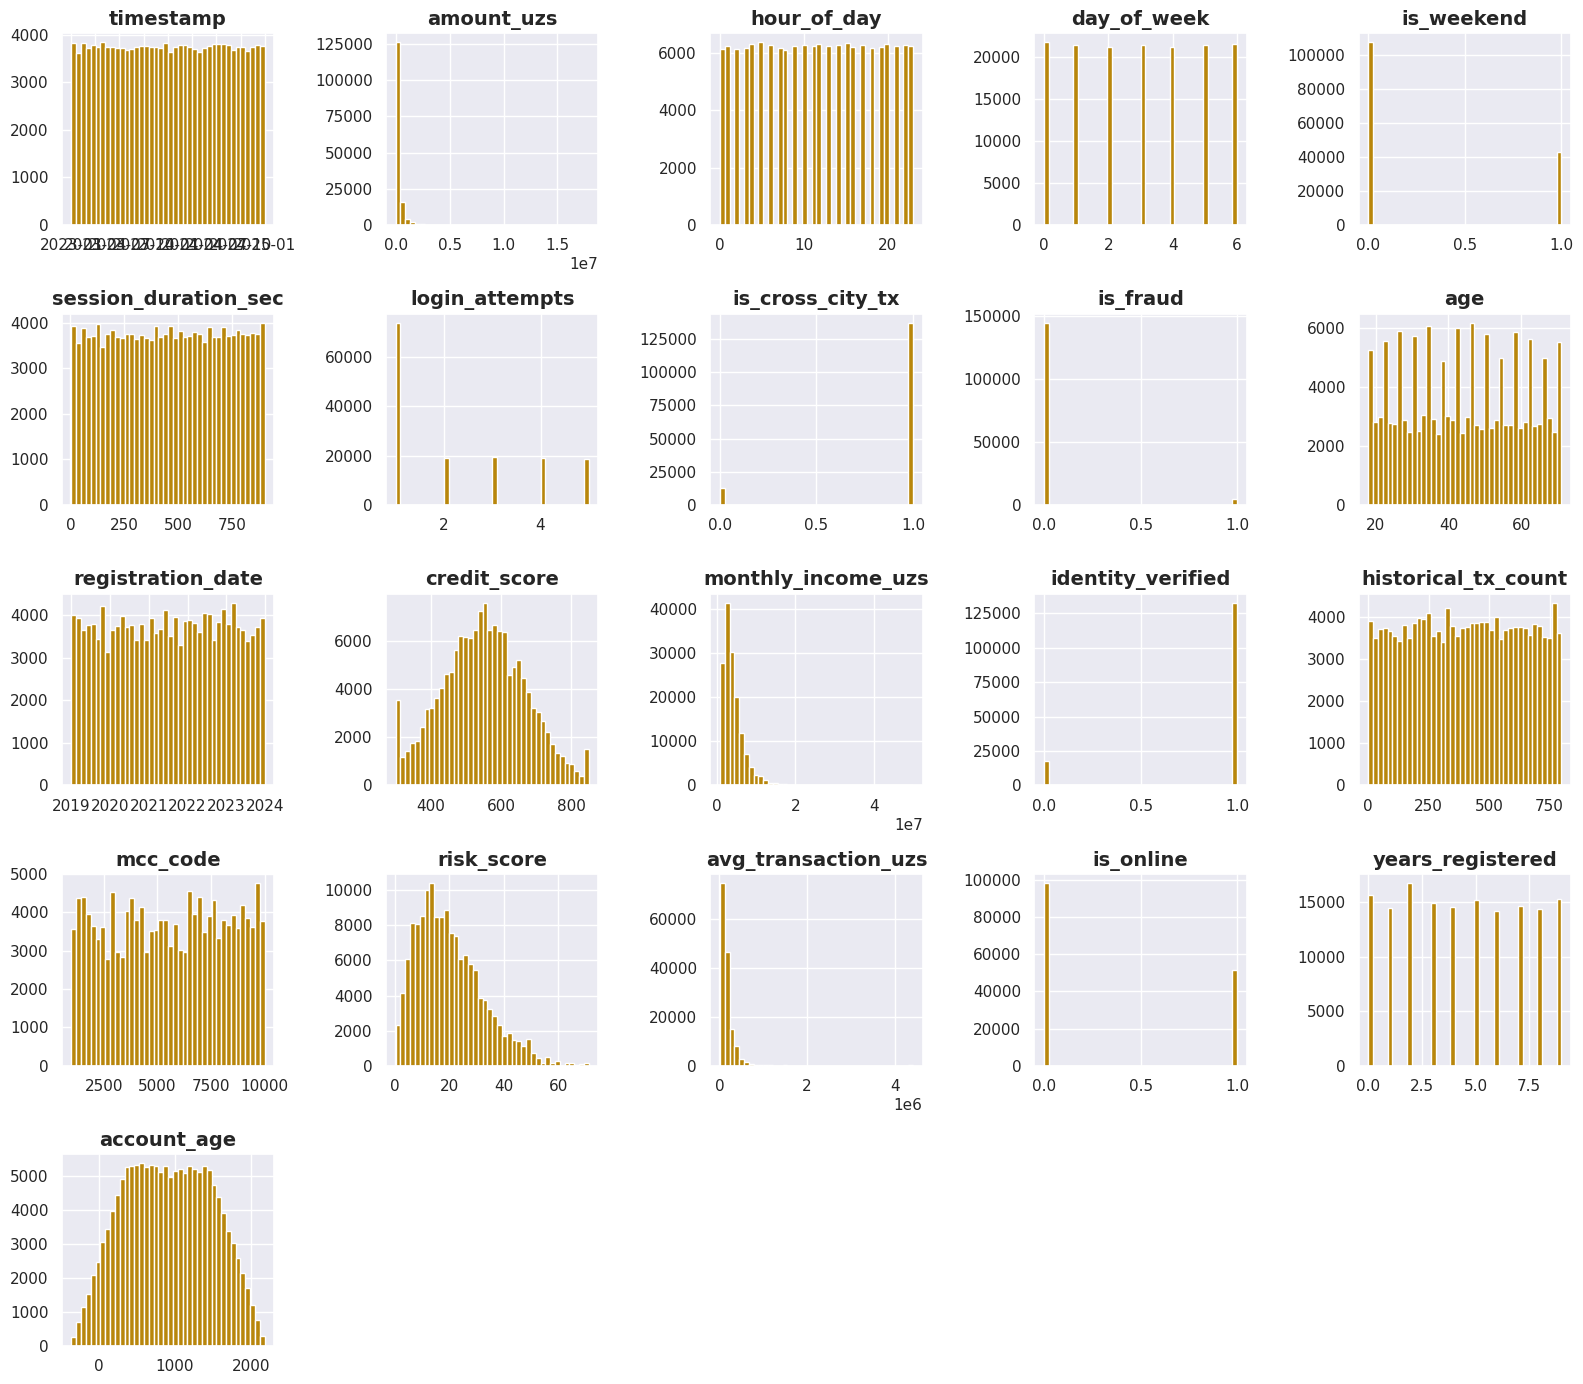

In [9]:
df.hist(figsize=(16, 14), bins=40)
plt.tight_layout()
plt.show()

Notable analysis:

In [10]:
exclude = [
    "tx_id",
    "name",
    "user_id",
    "merchant_id",
    "merchant_name",
    "timestamp",
    "registration_date",
]

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.difference(exclude).tolist()
num_cols = [c for c in num_cols if c not in exclude + ["is_fraud"]]

/tmp/ipykernel_128516/2213477999.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.difference(exclude).tolist()


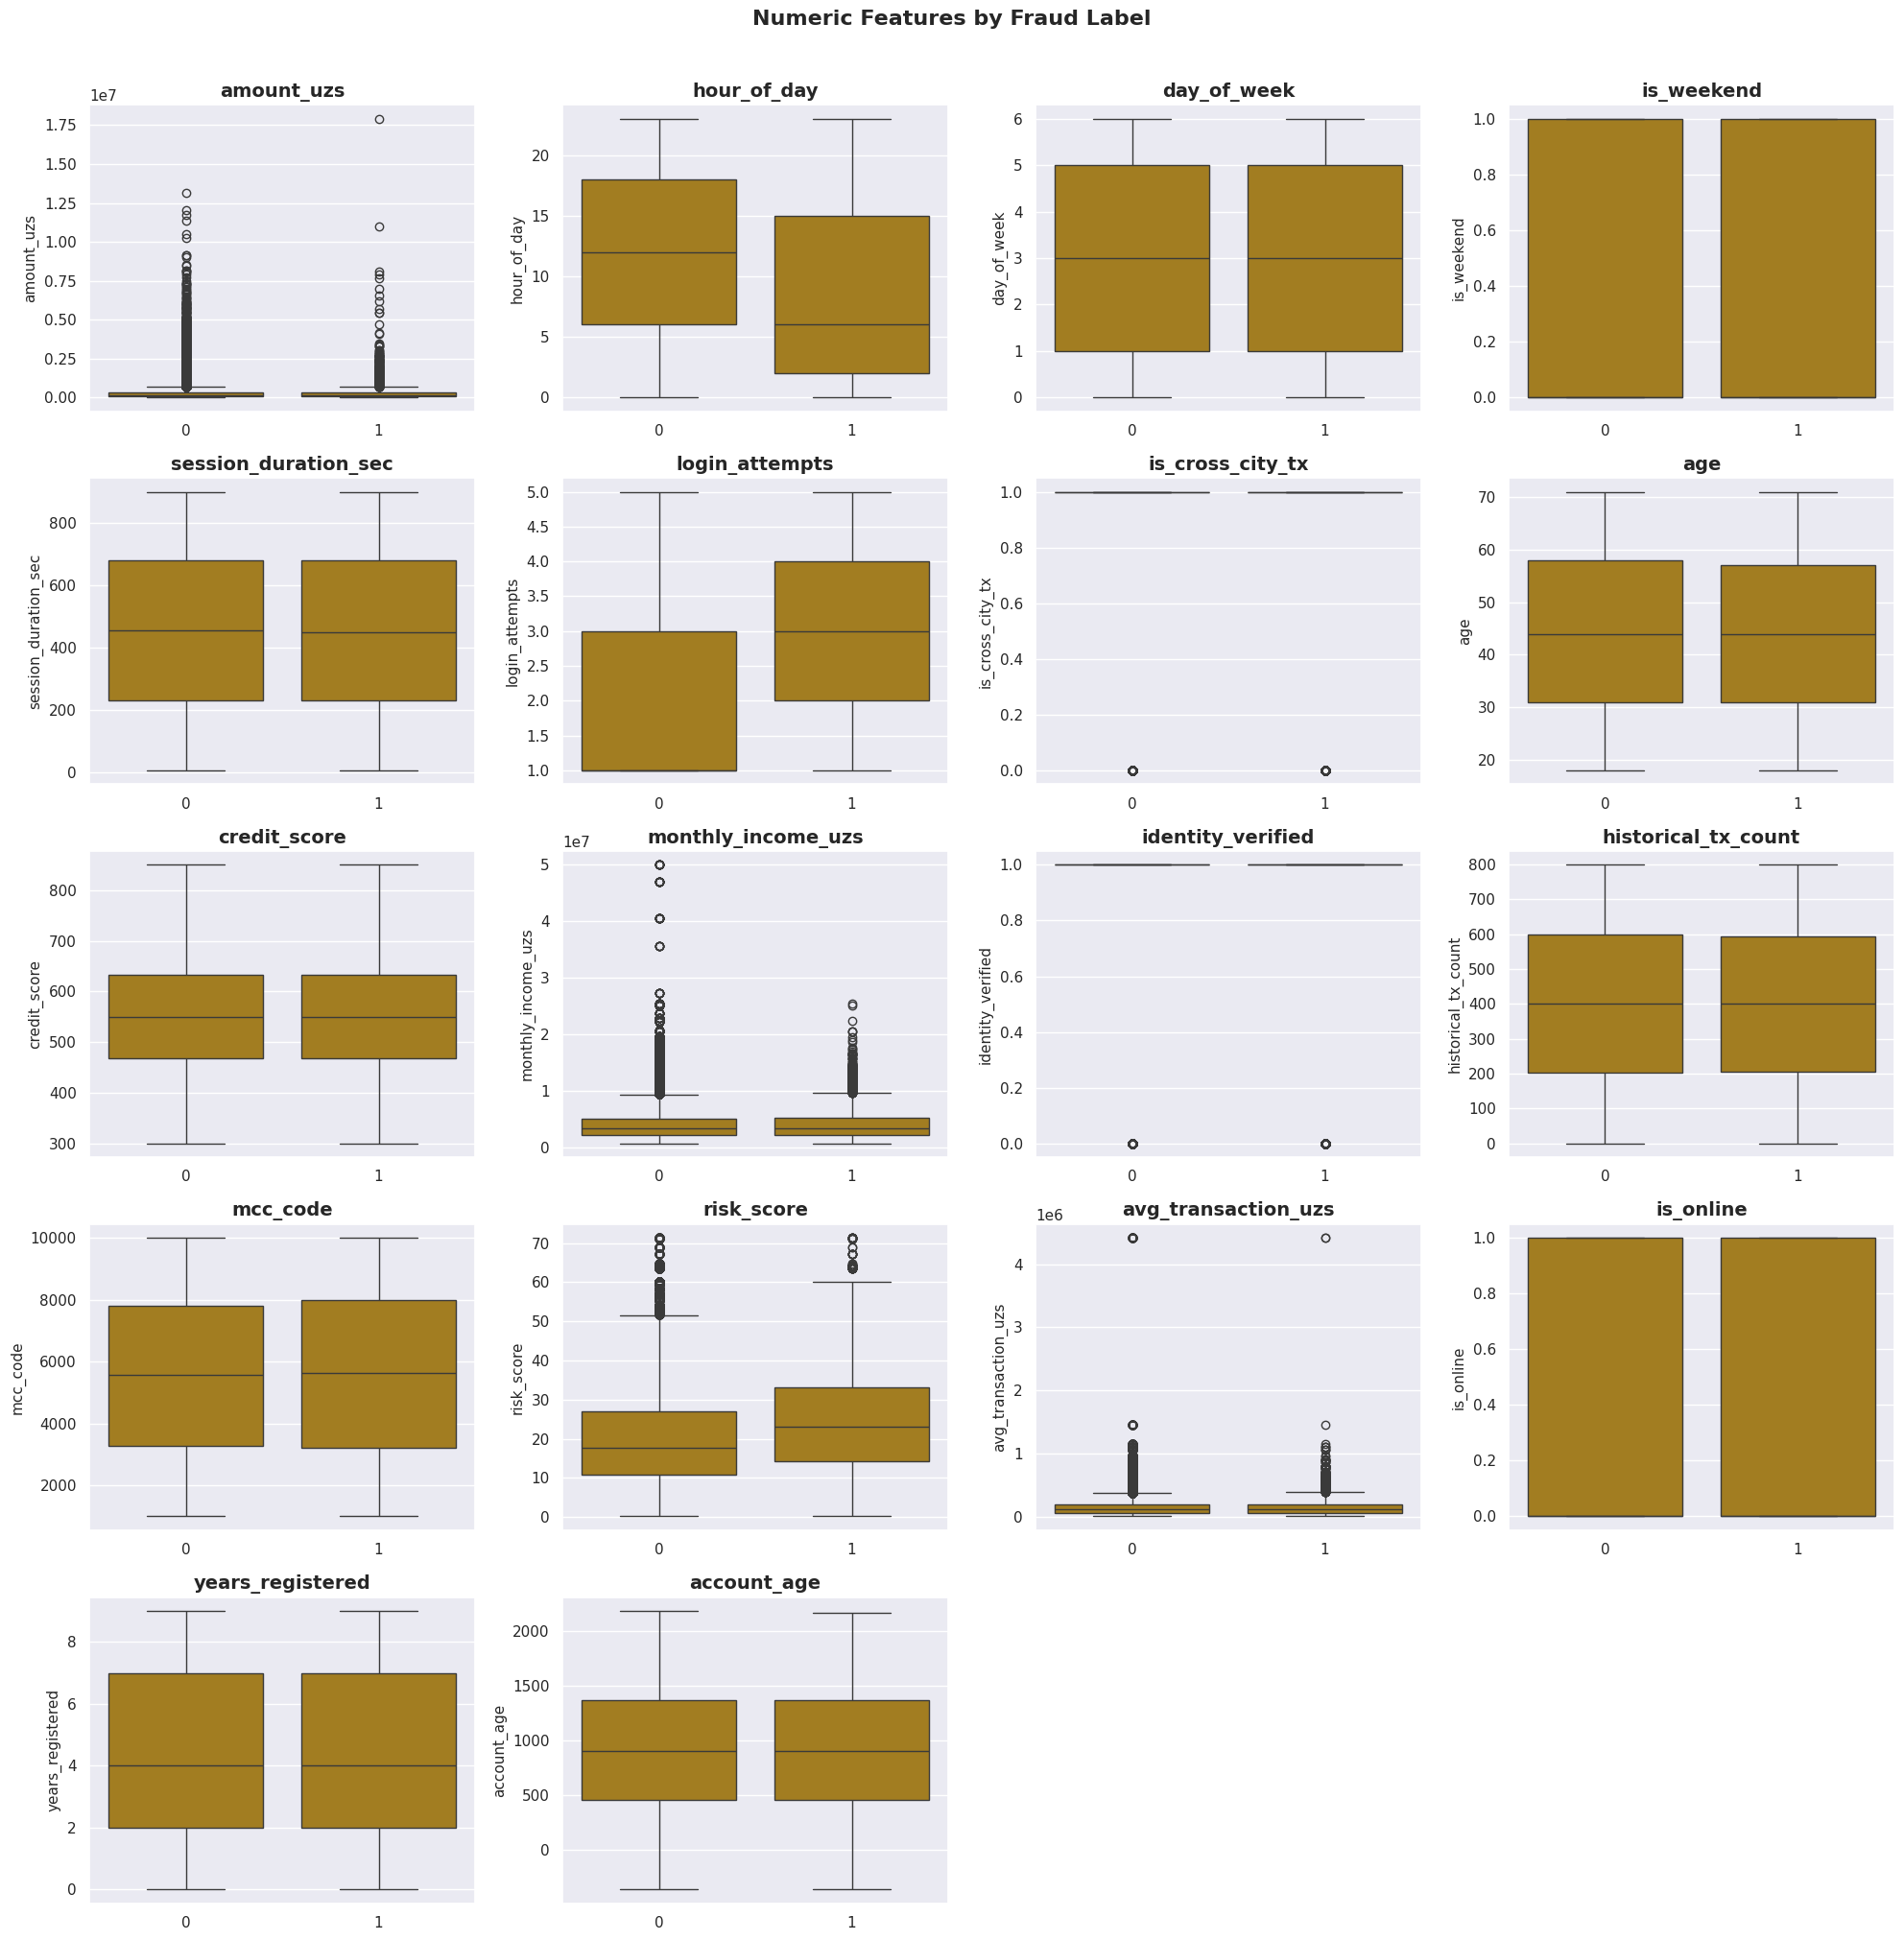

In [11]:
ncols = 4
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="is_fraud", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(num_cols) :]:
    ax.set_visible(False)

plt.suptitle("Numeric Features by Fraud Label", y=1.01)
plt.tight_layout()
plt.show()

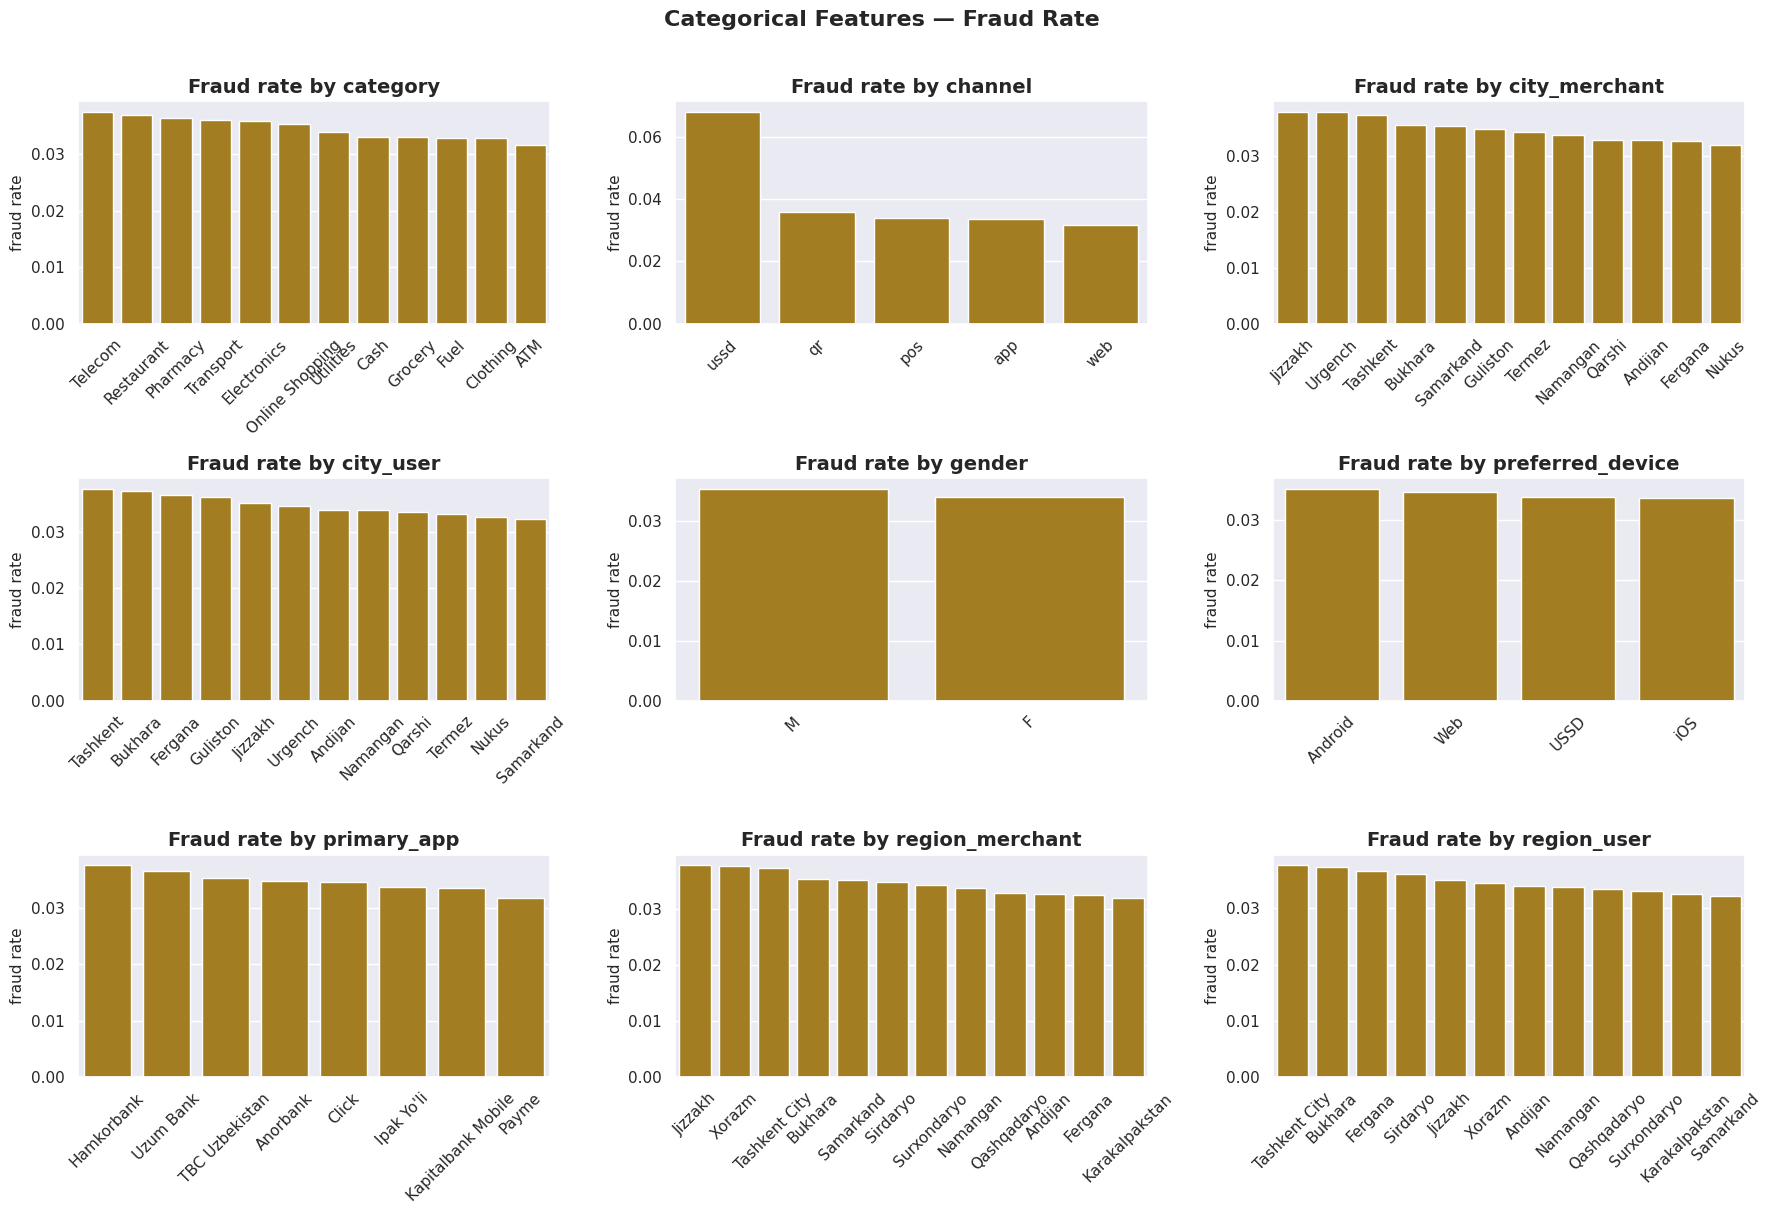

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    fraud_rate = df.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values, ax=ax)
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("fraud rate")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Categorical Features — Fraud Rate", y=1.01)
plt.tight_layout()
plt.show()

### Correlations

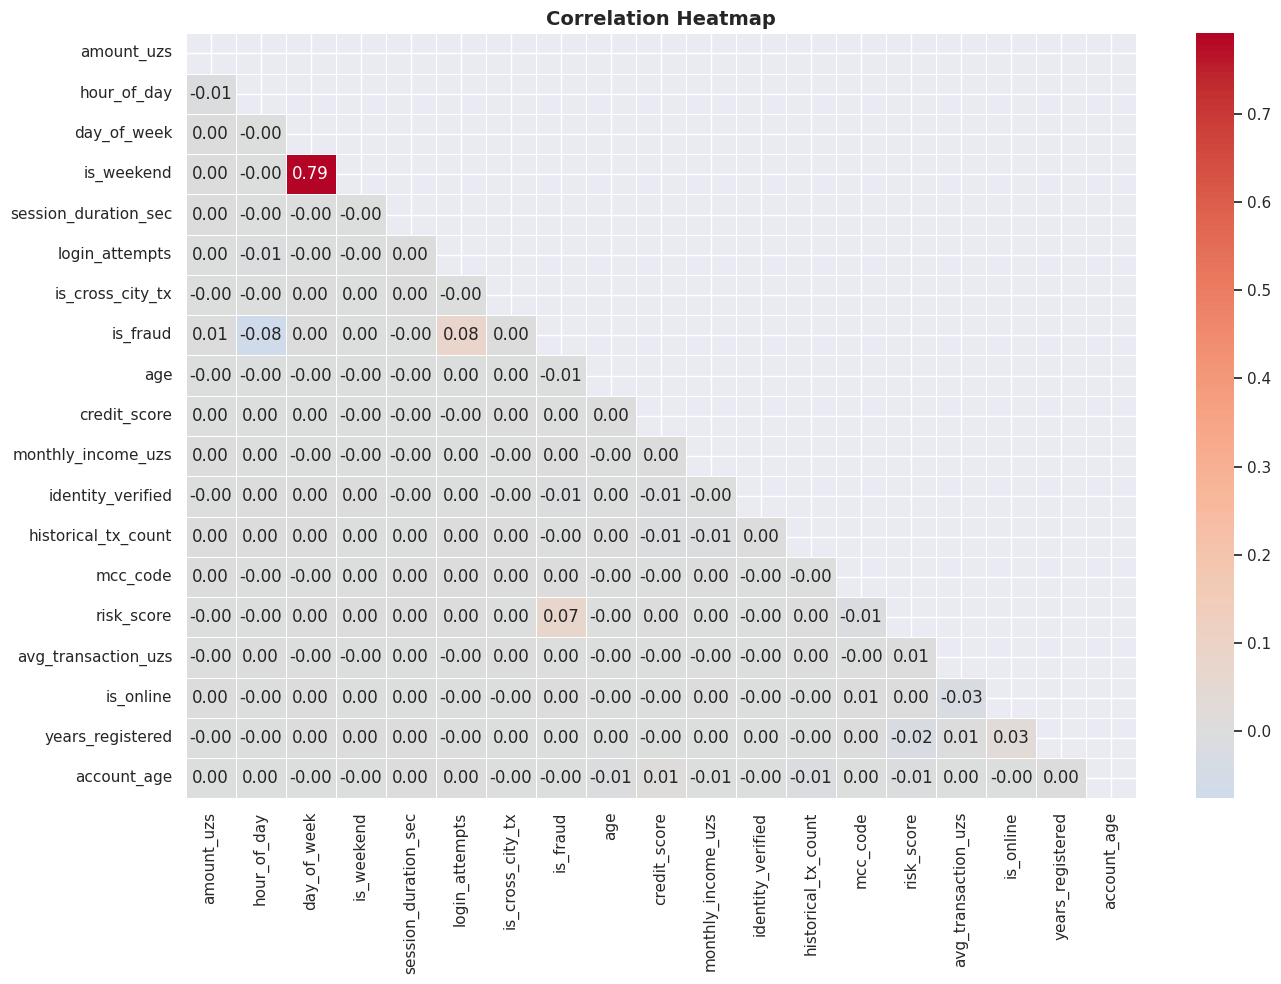

In [13]:
corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

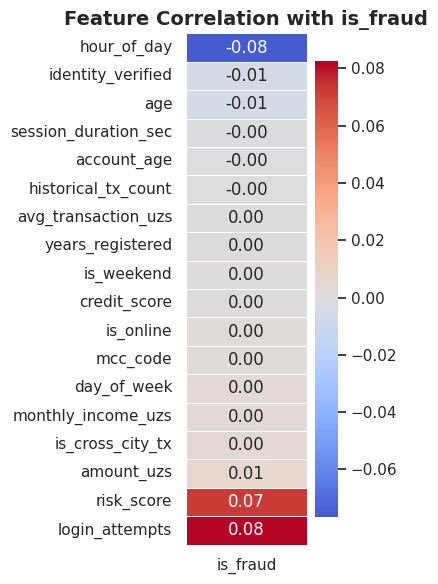

In [14]:
corr_fraud = (
    df.select_dtypes(include="number").corr()["is_fraud"].drop("is_fraud").sort_values()
)

fig, ax = plt.subplots(figsize=(4, 6))
sns.heatmap(
    corr_fraud.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
plt.title("Feature Correlation with is_fraud")
plt.tight_layout()
plt.show()

## Modelling

### Data Preparation

#### Splitting - 70/15/15

In [15]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]:,} rows ({len(X_train)/len(X):.0%})")
print(f"Validation: {X_val.shape[0]:,} rows ({len(X_val)/len(X):.0%})")
print(f"Test:       {X_test.shape[0]:,} rows ({len(X_test)/len(X):.0%})")
print(
    f"\nFraud rate - train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}"
)

Train:      105,000 rows (70%)
Validation: 22,500 rows (15%)
Test:       22,500 rows (15%)

Fraud rate - train: 3.47% | val: 3.47% | test: 3.47%


#### 🔧 Preprocessing Pipeline 

Handling class imbalance: chosen technique = balanced classes within models
- SMOTE
- Tuning threshold

In [16]:
drop_cols = ["tx_id", "user_id", "merchant_id", "merchant_name", "name"]

low_card_cats = ["gender", "channel", "preferred_device"]
high_card_cats = [
    "city_user",
    "city_merchant",
    "region_user",
    "region_merchant",
    "primary_app",
    "category",
]

num_cols = X_train.select_dtypes(include="number").columns.tolist()

In [17]:
print("drop:", drop_cols)
print("low_card:", low_card_cats)
print("high_card:", high_card_cats)
print("numeric:", num_cols)

all_handled = drop_cols + low_card_cats + high_card_cats + num_cols
unhandled = [c for c in X_train.columns if c not in all_handled]
print("unhandled:", unhandled)

drop: ['tx_id', 'user_id', 'merchant_id', 'merchant_name', 'name']
low_card: ['gender', 'channel', 'preferred_device']
high_card: ['city_user', 'city_merchant', 'region_user', 'region_merchant', 'primary_app', 'category']
numeric: ['amount_uzs', 'hour_of_day', 'day_of_week', 'is_weekend', 'session_duration_sec', 'login_attempts', 'is_cross_city_tx', 'age', 'credit_score', 'monthly_income_uzs', 'identity_verified', 'historical_tx_count', 'mcc_code', 'risk_score', 'avg_transaction_uzs', 'is_online', 'years_registered', 'account_age']
unhandled: ['timestamp', 'registration_date']


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_cols),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_card_cats,
        ),
        ("target_enc", TargetEncoder(), high_card_cats),
        ("num", StandardScaler(), num_cols),
    ]
)

### Baselines

In [19]:
strategies = ["most_frequent", "stratified", "uniform"]

for strategy in strategies:
    dummy = DummyClassifier(strategy=strategy, random_state=42)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_val)
    print(f"\n--- {strategy} ---")
    print(classification_report(y_val, y_pred, target_names=["not_fraud", "fraud"]))


--- most_frequent ---
              precision    recall  f1-score   support

   not_fraud       0.97      1.00      0.98     21719
       fraud       0.00      0.00      0.00       781

    accuracy                           0.97     22500
   macro avg       0.48      0.50      0.49     22500
weighted avg       0.93      0.97      0.95     22500


--- stratified ---
              precision    recall  f1-score   support

   not_fraud       0.96      0.96      0.96     21719
       fraud       0.02      0.03      0.03       781

    accuracy                           0.93     22500
   macro avg       0.49      0.49      0.49     22500
weighted avg       0.93      0.93      0.93     22500


--- uniform ---
              precision    recall  f1-score   support

   not_fraud       0.97      0.50      0.66     21719
       fraud       0.04      0.51      0.07       781

    accuracy                           0.50     22500
   macro avg       0.50      0.50      0.36     22500
weighted avg  

/home/linuxg/Desktop/Turing/fraud/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/linuxg/Desktop/Turing/fraud/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/linuxg/Desktop/Turing/fraud/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [20]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Light Gradient Boosting": LGBMClassifier(
        random_state=42, is_unbalance=True, verbose=-1
    ),
    "Extreme Gradient Boosting": XGBClassifier(
        random_state=42,
        scale_pos_weight=int((y_train == 0).sum() / (y_train == 1).sum()),
    ),
    "Logistic Regression": LogisticRegression(
        random_state=42, max_iter=1000, class_weight="balanced"
    ),
}

In [22]:
results = None
pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline

    y_proba_train = pipeline.predict_proba(X_train)[:, 1]
    y_proba_val = pipeline.predict_proba(X_val)[:, 1]

    y_pred_train = pipeline.predict(X_train)
    y_pred_val = pipeline.predict(X_val)

    results, new_results = score_predictions(
        y_pred_train,
        y_pred_val,
        y_train,
        y_val,
        y_proba_train,
        y_proba_val,
        f"Base {name}",
        "Defaults",
        results,
    )

new_results

,Model,PR AUC,F1 Score,Train F1,Precision,Recall,Params
0,Base Light Gradient Boosting,0.092,0.136,0.174,0.076,0.631,Defaults
1,Base Random Forest,0.083,0.000,0.869,0.000,0.000,Defaults
2,Base Extreme Gradient Boosting,0.078,0.141,0.312,0.087,0.385,Defaults
3,Base Logistic Regression,0.074,0.114,0.117,0.063,0.634,Defaults


In [23]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# study_lgbm = optuna.create_study(
#     direction="maximize",
#     sampler=TPESampler(seed=42),
#     pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
# )

# study_lgbm.optimize(
#     lambda trial: objective_lgbm,
#     preprocessor=preprocessor,
#     X_train=X_train,
#     y_train=y_train,
#     cv=cv,
#     n_trials=50,
# )

# print(f"Best PR AUC: {study_lgbm.best_value:.4f}")
# print(f"Best params: {study_lgbm.best_params}")

Best PR AUC: 0.1017
Best params: {'n_estimators': 273, 'learning_rate': 0.027152467999456278, 'max_depth': 3, 'num_leaves': 158, 'min_child_samples': 59, 'subsample': 0.7088012704946973, 'colsample_bytree': 0.5692800206726821, 'reg_alpha': 0.00016711945362849083, 'reg_lambda': 4.91378020643718e-06}

In [24]:
best_params_lgbm = {
    "n_estimators": 273,
    "learning_rate": 0.027152467999456278,
    "max_depth": 3,
    "num_leaves": 158,
    "min_child_samples": 59,
    "subsample": 0.7088012704946973,
    "colsample_bytree": 0.5692800206726821,
    "reg_alpha": 0.00016711945362849083,
    "reg_lambda": 4.91378020643718e-06,
}

In [25]:
lgbm_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMClassifier(
                **best_params_lgbm,
                is_unbalance=True,
                random_state=42,
                verbose=-1,
            ),
        ),
    ]
)
lgbm_pipeline.fit(X_train, y_train)
pipelines["Tuned LGBM"] = lgbm_pipeline

y_proba_train = lgbm_pipeline.predict_proba(X_train)[:, 1]
y_proba_val = lgbm_pipeline.predict_proba(X_val)[:, 1]
y_pred_train = lgbm_pipeline.predict(X_train)
y_pred_val = lgbm_pipeline.predict(X_val)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    "Tuned LGBM",
    best_params_lgbm,
    results,
)

new_results

,Model,PR AUC,F1 Score,Train F1,Precision,Recall,Params
0,Tuned LGBM,0.099,0.132,0.136,0.073,0.714,"{'n_estimators': 273, 'learning_rate': 0.02715..."
1,Base Light Gradient Boosting,0.092,0.136,0.174,0.076,0.631,Defaults
2,Base Random Forest,0.083,0.000,0.869,0.000,0.000,Defaults
3,Base Extreme Gradient Boosting,0.078,0.141,0.312,0.087,0.385,Defaults
4,Base Logistic Regression,0.074,0.114,0.117,0.063,0.634,Defaults


In [26]:
# study_xgb = optuna.create_study(
#     direction="maximize",
#     sampler=TPESampler(seed=42),
#     pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
# )

# study_xgb.optimize(
#     lambda trial: objective_xgb(trial, preprocessor, X_train, y_train, cv), n_trials=50
# )

# print(f"Best PR AUC: {study_xgb.best_value:.4f}")
# print(f"Best params: {study_xgb.best_params}")

Best PR AUC: 0.1543
Best params: {'n_estimators': 154, 'learning_rate': 0.016087007326810204, 'max_depth': 10, 'min_child_weight': 10, 'subsample': 0.6173126829473421, 'colsample_bytree': 0.650290773076727, 'reg_alpha': 0.00034990880168122814, 'reg_lambda': 0.00030351893458768146, 'gamma': 0.0004803693142348827}

In [27]:
best_params_xgb = {
    "n_estimators": 154,
    "learning_rate": 0.016087007326810204,
    "max_depth": 10,
    "min_child_weight": 10,
    "subsample": 0.6173126829473421,
    "colsample_bytree": 0.650290773076727,
    "reg_alpha": 0.00034990880168122814,
    "reg_lambda": 0.00030351893458768146,
    "gamma": 0.0004803693142348827,
}

In [28]:
xgb_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                **best_params_xgb,
                scale_pos_weight=int((y_train == 0).sum() / (y_train == 1).sum()),
                random_state=42,
                verbosity=0
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train)
pipelines["Tuned XGB"] = xgb_pipeline

y_proba_train = xgb_pipeline.predict_proba(X_train)[:, 1]
y_proba_val = xgb_pipeline.predict_proba(X_val)[:, 1]
y_pred_train = xgb_pipeline.predict(X_train)
y_pred_val = xgb_pipeline.predict(X_val)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    "Tuned XGB",
    best_params_xgb,
    results,
)

new_results

,Model,PR AUC,F1 Score,Train F1,Precision,Recall,Params
0,Tuned LGBM,0.099,0.132,0.136,0.073,0.714,"{'n_estimators': 273, 'learning_rate': 0.02715..."
1,Base Light Gradient Boosting,0.092,0.136,0.174,0.076,0.631,Defaults
2,Tuned XGB,0.089,0.153,0.275,0.092,0.444,"{'n_estimators': 154, 'learning_rate': 0.01608..."
3,Base Random Forest,0.083,0.000,0.869,0.000,0.000,Defaults
4,Base Extreme Gradient Boosting,0.078,0.141,0.312,0.087,0.385,Defaults
5,Base Logistic Regression,0.074,0.114,0.117,0.063,0.634,Defaults


In [ ]:
estimators = [
    (
        "lgbm",
        LGBMClassifier(
            **best_params_lgbm,
            is_unbalance=True,
            random_state=42,
            verbose=-1,
        ),
    ),
    (
        "xgb",
        XGBClassifier(
            **best_params_xgb,
            scale_pos_weight=int((y_train == 0).sum() / (y_train == 1).sum()),
            random_state=42,
            verbosity=0,
        ),
    ),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

pipeline_stack = Pipeline([("preprocessor", preprocessor), ("model", stack)])
pipeline_stack.fit(X_train, y_train)
pipelines["Stacking"] = pipeline_stack

y_proba_train = pipeline_stack.predict_proba(X_train)[:, 1]
y_proba_val = pipeline_stack.predict_proba(X_val)[:, 1]
y_pred_train = pipeline_stack.predict(X_train)
y_pred_val = pipeline_stack.predict(X_val)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    "Stacked LGBM + XGB + LR",
    "Best params LGBM & XGB + meta-learner LR",
    results,
)
new_results

,Model,PR AUC,F1 Score,Train F1,Precision,Recall,Params
0,Stacked LGBM + XGB + LR,0.100,0.131,0.131,0.072,0.726,Best params LGBM & XGB + meta-learner LR
1,Tuned LGBM,0.099,0.132,0.136,0.073,0.714,"{'n_estimators': 273, 'learning_rate': 0.02715..."
2,Base Light Gradient Boosting,0.092,0.136,0.174,0.076,0.631,Defaults
3,Tuned XGB,0.089,0.153,0.275,0.092,0.444,"{'n_estimators': 154, 'learning_rate': 0.01608..."
4,Base Random Forest,0.083,0.000,0.869,0.000,0.000,Defaults
5,Base Extreme Gradient Boosting,0.078,0.141,0.312,0.087,0.385,Defaults
6,Base Logistic Regression,0.074,0.114,0.117,0.063,0.634,Defaults


In [ ]:
ss

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

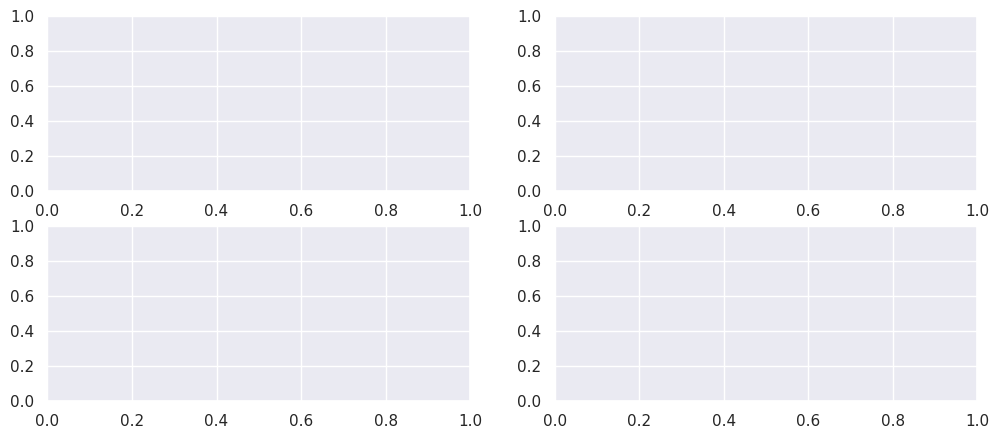

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))

for ax, (model_name, pipeline) in zip(axes, pipelines.items()):
    y_proba_val = pipeline.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_val)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    ax.plot(recalls, precisions)
    ax.scatter(
        recalls[best_idx],
        precisions[best_idx],
        color="darkgoldenrod",
        zorder=5,
        label=f"Best threshold: {best_threshold:.2f}",
    )
    ax.set_title(model_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

plt.suptitle("Precision-Recall Curves", y=1.01)
plt.tight_layout()
plt.show()